In [1]:
# Set the path to include the project root and change working directory
import sys
sys.path.append("/Users/hardikchauhan/fake-news-detector")
import os
os.chdir("/Users/hardikchauhan/fake-news-detector")

# Fake News Detector - EDA and Modeling

This notebook explores the fake news dataset and builds a classification model.

## Steps:
1. Load and explore the dataset
2. Text preprocessing
3. Feature engineering (TF-IDF)
4. Model training and evaluation
5. Error analysis
6. Model explainability with LIME
7. Saving the model and vectorizer

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_data, preprocess_pipeline
import re
import warnings
warnings.filterwarnings('ignore')

# For reproducibility
np.random.seed(42)

# Load dataset

NOTE: You need to download the dataset from Kaggle first:
https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
Place Fake.csv and True.csv in the data/ directory

In [3]:
# Uncomment and run after downloading data:
df = load_data('data/Fake.csv', 'data/True.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (44898, 6)


,title,text,subject,date,label,content
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0,Donald Trump Sends Out Embarrassing New Year’...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0,Drunk Bragging Trump Staffer Started Russian ...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0,Sheriff David Clarke Becomes An Internet Joke...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0,Trump Is So Obsessed He Even Has Obama’s Name...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0,Pope Francis Just Called Out Donald Trump Dur...


# Sample Data Structure (for reference)

Once you have the data, it will have columns like:
- : News headline
- : Article body
- : News topic
- Sat Sep  5 00:22:27 IST 2026: Publication date
- : 0 for fake, 1 for real (added during loading)

In [4]:
# Basic info
print(df.info())
print(f"\nFake news count: {df['label'].value_counts()[0]}")
print(f"Real news count: {df['label'].value_counts()[1]}")

# Check for missing values
print(f"\nMissing values:\n{df.isnull().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
 5   content  44898 non-null  object
dtypes: int64(1), object(5)
memory usage: 2.1+ MB
None

Fake news count: 23481
Real news count: 21417

Missing values:
title      0
text       0
subject    0
date       0
label      0
content    0
dtype: int64


## Text length analysis

We'll look at the length of the text and content (title + text).

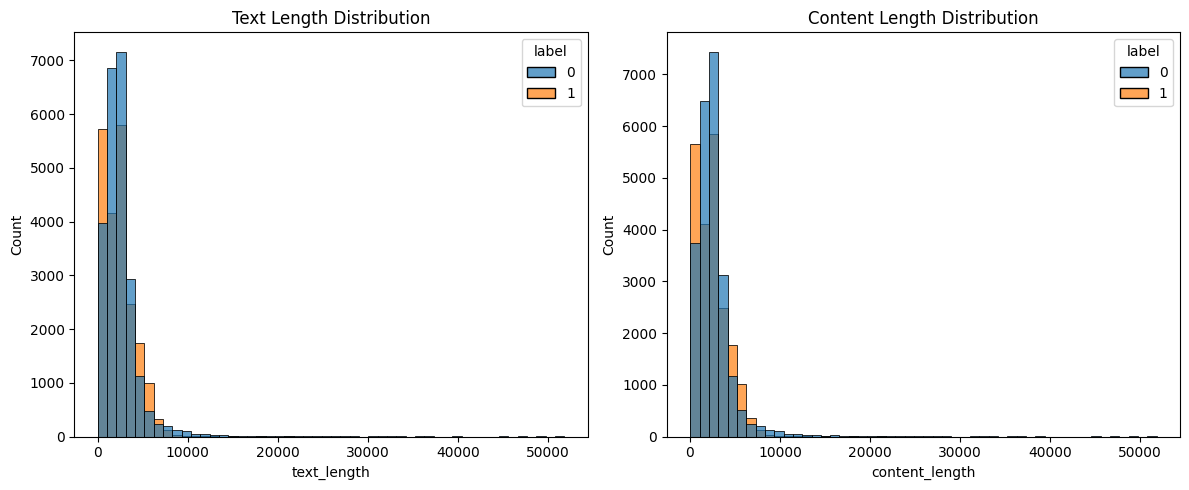

In [5]:
# Text length analysis
df['text_length'] = df['text'].str.len()
df['content_length'] = df['content'].str.len()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='text_length', hue='label', bins=50, alpha=0.7)
plt.title('Text Length Distribution')
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='content_length', hue='label', bins=50, alpha=0.7)
plt.title('Content Length Distribution')
plt.tight_layout()
plt.show()

## Text Preprocessing

We'll apply our preprocessing pipeline to the content column.

In [6]:
# Apply preprocessing
df['cleaned_content'] = df['content'].apply(preprocess_pipeline)
df[['content', 'cleaned_content']].head()

,content,cleaned_content
0,Donald Trump Sends Out Embarrassing New Year’...,donald trump send embarrass new year’ eve mess...
1,Drunk Bragging Trump Staffer Started Russian ...,drunk brag trump staffer start russian collus ...
2,Sheriff David Clarke Becomes An Internet Joke...,sheriff david clark becom internet joke threat...
3,Trump Is So Obsessed He Even Has Obama’s Name...,trump obsess even obama’ name code websit imag...
4,Pope Francis Just Called Out Donald Trump Dur...,pope franci call donald trump christma speech ...


## Feature Engineering: TF-IDF

Convert text to numerical features using TF-IDF vectorization.

In [ ]:
# From sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Prepare features and target
X = df['cleaned_content']
y = df['label']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Try different TF-IDF configurations
tfidf_configs = [
    {"max_features": 5000, "ngram_range": (1, 1), "name": "Unigram_5k"},
    {"max_features": 5000, "ngram_range": (1, 2), "name": "Bigram_5k"},
    {"max_features": 10000, "ngram_range": (1, 2), "name": "Bigram_10k"},
    {"max_features": 5000, "ngram_range": (1, 3), "name": "Trigram_5k"}
]

# Store results
results = []

for config in tfidf_configs:
    print(f"\n{'='*50}")
    print(f"Testing TF-IDF config: {config['name']}")
    print(f"{'='*50}")
    
    # TF-IDF Vectorization
    tfidf = TfidfVectorizer(max_features=config['max_features'], 
                           ngram_range=config['ngram_range'])
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)
    
    print(f"Features: {X_train_tfidf.shape[1]}")
    
    # Try different models
    models = [
        ("Logistic Regression", LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')),
        ("SVM", SVC(random_state=42, probability=True, class_weight='balanced')),
        ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')),
        ("Gradient Boosting", GradientBoostingClassifier(random_state=42))
    ]
    
    for model_name, model in models:
        # Train model
        model.fit(X_train_tfidf, y_train)
        
        # Predictions
        y_pred = model.predict(X_test_tfidf)
        y_pred_proba = model.predict_proba(X_test_tfidf)
        
        # Evaluate
        accuracy = accuracy_score(y_test, y_pred)
        
        # Store results
        results.append({
            'tfidf_config': config['name'],
            'model': model_name,
            'accuracy': accuracy,
            'tfidf_object': tfidf,
            'model_object': model
        })
        
        print(f"{model_name}: Accuracy = {accuracy:.4f}")

# Find best performing model
best_result = max(results, key=lambda x: x['accuracy'])
print(f"\n{'='*60}")
print(f"BEST MODEL: {best_result['model']} with {best_result['tfidf_config']}")
print(f"Accuracy: {best_result['accuracy']:.4f}")
print(f"{'='*60}")

# Use the best model and vectorizer for further analysis
best_tfidf = best_result['tfidf_object']
best_model = best_result['model_object']

# Transform data with best TF-IDF
X_train_best = best_tfidf.transform(X_train)
X_test_best = best_tfidf.transform(X_test)

# Get predictions from best model
y_pred_best = best_model.predict(X_test_best)
y_pred_proba_best = best_model.predict_proba(X_test_best)

print(f"\nBest model performance details:")
print(classification_report(y_test, y_pred_best, target_names=['Fake', 'Real']))

## Model Training

We'll compare multiple classifiers with different TF-IDF configurations to find the best performing model.

The model comparison has been moved to the TF-IDF configuration testing section above.

In [ ]:
## Model Training - Individual Models (MOVED TO COMPREHENSIVE COMPARISON ABOVE)

For detailed model comparison with multiple TF-IDF configurations, see the previous cell.
The best performing model from that comparison will be used for subsequent analysis.

In [ ]:
## Model Training - Individual Models (MOVED TO COMPREHENSIVE COMPARISON ABOVE)

For detailed model comparison with multiple TF-IDF configurations, see the previous cell.
The best performing model from that comparison will be used for subsequent analysis.

## Feature Engineering: Adding Text Features

Let's enhance our TF-IDF features with additional text-based features that might help the model.

We'll create features like:
- Text length
- Number of exclamation marks
- Number of question marks  
- Ratio of capital letters
- Average word length
- etc.

Then we'll combine these with our TF-IDF features.

In [ ]:
# Extract text-based features
def extract_text_features(texts):
    """Extract various text-based features"""
    features = []
    
    for text in texts:
        # Basic text stats
        length = len(text)
        word_count = len(text.split()) if text.strip() else 0
        avg_word_length = np.mean([len(word) for word in text.split()]) if word_count > 0 else 0
        
        # Punctuation counts
        exclam_count = text.count('!')
        quest_count = text.count('?')
        period_count = text.count('.')
        comma_count = text.count(',')
        
        # Capitalization features
        upper_count = sum(1 for c in text if c.isupper())
        upper_ratio = upper_count / length if length > 0 else 0
        
        # Special character counts
        digit_count = sum(1 for c in text if c.isdigit())
        
        features.append([
            length, word_count, avg_word_length,
            exclam_count, quest_count, period_count, comma_count,
            upper_ratio, digit_count
        ])
    
    return np.array(features)

# Extract features for train and test sets
print("Extracting text-based features...")
X_train_text_features = extract_text_features(X_train)
X_test_text_features = extract_text_features(X_test)

print(f"Text features shape: {X_train_text_features.shape}")
print(f"Feature names: ['length', 'word_count', 'avg_word_length', 'exclam_count', 'quest_count', 'period_count', 'comma_count', 'upper_ratio', 'digit_count']")

# Combine with TF-IDF features from our best configuration
# We'll use the best TF-IDF from our previous comparison
# But let's recompute it here for clarity with a good configuration
tfidf_for_features = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf_features = tfidf_for_features.fit_transform(X_train)
X_test_tfidf_features = tfidf_for_features.transform(X_test)

# Combine TF-IDF and text features
from scipy.sparse import hstack
X_train_combined = hstack([X_train_tfidf_features, X_train_text_features])
X_test_combined = hstack([X_test_tfidf_features, X_test_text_features])

print(f"Combined features shape: {X_train_combined.shape}")
print(f"TF-IDF features: {X_train_tfidf_features.shape[1]}")
print(f"Text features: {X_train_text_features.shape[1]}")

# Train a few models on combined features
print("\nTraining models on combined TF-IDF + text features:")
models_combined = [
    ("Logistic Regression", LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')),
    ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')),
]

for model_name, model in models_combined:
    model.fit(X_train_combined, y_train)
    y_pred = model.predict(X_test_combined)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{model_name} (Combined Features): Accuracy = {accuracy:.4f}")

## Ensemble Methods: Combining Multiple Models

Let's create an ensemble model that combines the predictions of multiple strong performers.
We'll use a VotingClassifier (soft voting) that averages the probabilities.

First, let's define several strong base models using our best TF-IDF configuration
(from our earlier comparison) or we can use the combined features approach.
Let's use the TF-IDF features for the ensemble to keep it consistent with our earlier analysis.

In [ ]:
# Create ensemble model using TF-IDF features (from our best configuration)
# Let's use a good TF-IDF configuration for consistency
tfidf_ensemble = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf_ens = tfidf_ensemble.fit_transform(X_train)
X_test_tfidf_ens = tfidf_ensemble.transform(X_test)

# Define base models for ensemble
base_models = [
    ('lr', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')),
    ('gb', GradientBoostingClassifier(random_state=42))
]

# Create voting classifier (soft voting)
ensemble_model = VotingClassifier(
    estimators=base_models,
    voting='soft'  # uses predicted probabilities
)

# Train ensemble
print("Training ensemble model...")
ensemble_model.fit(X_train_tfidf_ens, y_train)

# Evaluate ensemble
y_pred_ens = ensemble_model.predict(X_test_tfidf_ens)
y_pred_proba_ens = ensemble_model.predict_proba(X_test_tfidf_ens)
accuracy_ens = accuracy_score(y_test, y_pred_ens)

print(f"Ensemble Model Accuracy: {accuracy_ens:.4f}")
print("\nEnsemble Model Classification Report:")
print(classification_report(y_test, y_pred_ens, target_names=['Fake', 'Real']))

# Compare with our individual best model from earlier
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(f"Best individual model (from TF-IDF comparison): {best_result['accuracy']:.4f}")
print(f"Ensemble model: {accuracy_ens:.4f}")
print(f"Improvement: {accuracy_ens - best_result['accuracy']:.4f}")

# Use the better of the two for final model
if accuracy_ens > best_result['accuracy']:
    print("\n✓ Ensemble model performs better - using ensemble for final model")
    final_model = ensemble_model
    final_tfidf = tfidf_ensemble
else:
    print("\n✓ Best individual model performs better - using individual model for final model")
    final_model = best_model
    final_tfidf = best_tfidf

print(f"Selected final model accuracy: {max(accuracy_ens, best_result['accuracy']):.4f}")

# Generate predictions using our final model and TF-IDF vectorizer
X_test_final = final_tfidf.transform(X_test)
y_pred_final = final_model.predict(X_test_final)
y_pred_proba_final = final_model.predict_proba(X_test_final)

# Plot confusion matrix for our final model
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
             xticklabels=['Fake', 'Real'],
             yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix - Final Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
## Error Analysis

Let's look at some examples the model got wrong to understand its limitations.

# Find misclassified examples using our final model
misclassified_idx = y_test != y_pred_final
X_test_misclassified = X_test[misclassified_idx]
y_test_misclassified = y_test[misclassified_idx]
y_pred_misclassified = y_pred_final[misclassified_idx]

print(f"Number of misclassified samples: {len(X_test_misclassified)}")

# Show a few examples
for i in range(min(3, len(X_test_misclassified))):
    print(f"\nExample {i+1}:")
    print(f"True label: {'Real' if y_test_misclassified.iloc[i] == 1 else 'Fake'}")
    print(f"Predicted: {'Real' if y_pred_misclassified[i] == 1 else 'Fake'}")
    print(f"Text preview: {X_test_misclassified.iloc[i][:200]}...")

In [ ]:
## Model Explainability with LIME

Let's use LIME (Local Interpretable Model-agnostic Explanations) to understand what words are driving our predictions.

# Import LIME
from lime.lime_text import LimeTextExplainer

# Define prediction function for LIME (same preprocessing as training)
def predict_proba_lime(texts):
    # texts is a list of raw text strings
    cleaned = [preprocess_pipeline(text) for text in texts]
    vectorized = final_tfidf.transform(cleaned)
    return final_model.predict_proba(vectorized)

# Create explainer
explainer = LimeTextExplainer(class_names=['Fake', 'Real'])

# Explain a few predictions
print("Explaining predictions for a few test samples...")
for i in range(min(5, len(X_test))):
    exp = explainer.explain_instance(
        X_test.iloc[i],
        predict_proba_lime,
        num_features=6
    )
    print(f"\nSample {i+1}:")
    print(f"True label: {'Real' if y_test.iloc[i] == 1 else 'Fake'}")
    print(f"Predicted: {'Real' if final_model.predict(final_tfidf.transform([X_test.iloc[i]]))[0] == 1 else 'Fake'}")
    print("Top words contributing to prediction:")
    for word, weight in exp.as_list():
        print(f"  {word}: {weight:.4f}")

# Saving the Final Model and Vectorizer

# Import joblib for saving
import joblib

# Save the final model and vectorizer
joblib.dump(final_model, 'src/fake_news_model.pkl')
joblib.dump(final_tfidf, 'src/tfidf_vectorizer.pkl')
print("Final model and vectorizer saved successfully!")